# Project Pipeline — Factor-Based Asset Return Model

This notebook runs the full project end-to-end, stage by stage: generate data → store → clean →
outliers → EDA → features → model → evaluate → report → save the model for the Flask API.
It is the single artifact that proves every stage still works.

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')   # project/notebooks -> project
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))   # so `from src....` imports work
print('working from:', ROOT.name)

working from: project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import scipy.stats as st
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from src import config, utils, cleaning, outliers, eda, features, evaluation

sns.set(context='notebook', style='whitegrid')
np.random.seed(config.RANDOM_SEED)
config.ensure_dirs()
print('config: RAW=', config.DATA_DIR_RAW, 'PROCESSED=', config.DATA_DIR_PROCESSED)
print('seed =', config.RANDOM_SEED)

config: RAW= /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/project/data/raw PROCESSED= /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/project/data/processed
seed = 42


## Stage 4 — Data acquisition (generate the self-contained dataset)

In [3]:
df = utils.generate_factor_data(seed=config.RANDOM_SEED)
raw_path = config.DATA_DIR_RAW / 'factor_returns.csv'
utils.save_dataframe(df, raw_path)
print('saved raw data:', raw_path, '| shape', df.shape)
df.head()

saved raw data: /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/project/data/raw/factor_returns.csv | shape (250, 6)


,date,mkt_excess,size,value,momentum,asset_excess
0,2023-01-03,0.003352,-0.002946,0.012275,0.000069,0.000256
1,2023-01-04,-0.011440,0.002732,0.008057,-0.001796,-0.018062
2,2023-01-05,0.008255,0.013830,-0.006475,-0.006090,0.006795
3,2023-01-06,0.010346,-0.007895,-0.013523,0.012293,0.019795
4,2023-01-09,-0.021461,-0.001962,-0.026681,0.010711,-0.011511


## Stage 5 — Data storage (CSV + Parquet round-trip)

In [4]:
csv_back = utils.load_dataframe(raw_path)
parquet_path = config.DATA_DIR_PROCESSED / 'factor_returns.parquet'
utils.save_dataframe(csv_back, parquet_path)
pq_back = utils.load_dataframe(parquet_path)
print('CSV rows:', len(csv_back), '| Parquet rows:', len(pq_back))
print('round-trip identical:', csv_back.equals(pq_back))

CSV rows: 250 | Parquet rows: 250
round-trip identical: True


## Stage 6 — Data preprocessing (clean missing values)

In [5]:
print('missing before:', df[['value', 'momentum', 'mkt_excess', 'size']].isna().sum().to_dict())
df_clean = cleaning.fill_missing_median(df, columns=['value'])   # median impute
print('missing after :', df_clean[['value', 'momentum', 'mkt_excess', 'size']].isna().sum().to_dict())
clean_path = config.DATA_DIR_PROCESSED / 'cleaned_data.csv'
utils.save_dataframe(df_clean, clean_path)

missing before: {'value': 12, 'momentum': 0, 'mkt_excess': 0, 'size': 0}
missing after : {'value': 0, 'momentum': 0, 'mkt_excess': 0, 'size': 0}


PosixPath('/Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/project/data/processed/cleaned_data.csv')

## Stage 7 — Outlier analysis (flag + winsorize momentum)

In [6]:
mom = df_clean['momentum']
iqr_flag = outliers.detect_outliers_iqr(mom, k=1.5)
z_flag = outliers.detect_outliers_zscore(mom, threshold=3.0)
print('IQR flags:', int(iqr_flag.sum()), '| Z-score flags:', int(z_flag.sum()))
df_clean['momentum'] = outliers.winsorize_series(mom, lower=0.01, upper=0.99)
print('momentum max after winsorize: %.5f (was %.5f)' % (df_clean['momentum'].max(), mom.max()))

IQR flags: 6 | Z-score flags: 3
momentum max after winsorize: 0.01292 (was 0.04907)


## Stage 8 — EDA (profile the dataset)

In [7]:
summary = eda.eda_summary(df_clean)
print('shape:', summary['shape'])
print('missing:', summary['missing'])
summary['numeric_profile'][['mean', 'std', 'skew', 'kurtosis']].round(4)

shape: (250, 6)
missing: {'date': 0, 'mkt_excess': 0, 'size': 0, 'value': 0, 'momentum': 0, 'asset_excess': 0}


,mean,std,skew,kurtosis
mkt_excess,-0.0005,0.0103,0.3847,0.1368
size,0.0002,0.0078,-0.1731,-0.1464
value,-0.0008,0.0089,-0.0744,0.0497
momentum,0.0002,0.0059,-0.1838,-0.0650
asset_excess,-0.0002,0.0133,0.0964,1.7033


In [8]:
# Which factors matter for the target?
corr = df_clean[['mkt_excess', 'size', 'value', 'momentum', 'asset_excess']].corr(numeric_only=True)
corr['asset_excess'].drop('asset_excess').round(3)

mkt_excess    0.731
size          0.201
value        -0.178
momentum      0.160
Name: asset_excess, dtype: float64

## Stage 9 — Feature engineering (quadratic + lag + rolling)

In [9]:
df_feat = features.create_features(df_clean)
new_cols = [c for c in df_feat.columns if c not in df_clean.columns]
print('new features:', new_cols)
df_feat[['momentum', 'momentum_sq', 'asset_excess_lag1', 'asset_excess_rollstd_20']].head()

new features: ['momentum_sq', 'asset_excess_lag1', 'asset_excess_rollmean_5', 'asset_excess_rollstd_20']


,momentum,momentum_sq,asset_excess_lag1,asset_excess_rollstd_20
0,0.000069,4.720755e-09,NaN,NaN
1,-0.001796,3.224137e-06,0.000256,NaN
2,-0.006090,3.709306e-05,-0.018062,NaN
3,0.012293,1.511064e-04,0.006795,NaN
4,0.010711,1.147257e-04,0.019795,NaN


## Stage 10a/10b — Modeling (factor regression, time-ordered split)

In [10]:
FEATURES = ['mkt_excess', 'size', 'value', 'momentum']
X = df_clean[FEATURES].to_numpy()
y = df_clean['asset_excess'].to_numpy()

# Time-ordered split: train on the past, test on the most recent 20%.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R2 = {r2:.4f}   RMSE = {rmse:.5f}   (n_test={len(y_test)})')
print('\ncoefficients (factor exposure):')
for name, b in zip(FEATURES, model.coef_):
    print(f'  {name:12s} {b:+.4f}')
print(f'  {"intercept":12s} {model.intercept_:+.6f}')

R2 = 0.5288   RMSE = 0.00996   (n_test=50)

coefficients (factor exposure):
  mkt_excess   +1.0121
  size         +0.2591
  value        -0.2304
  momentum     +0.4765
  intercept    +0.000302


## Residual diagnostics

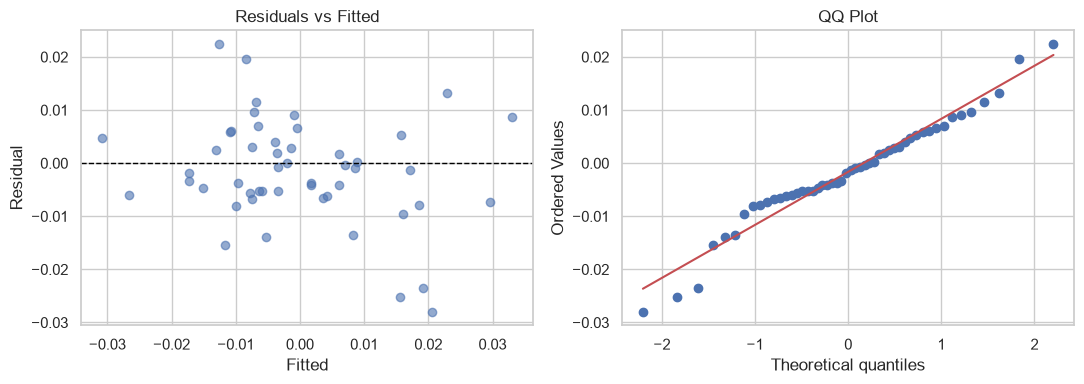

In [11]:
resid = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_pred, resid, alpha=0.6)
axes[0].axhline(0, color='black', ls='--', lw=1)
axes[0].set_xlabel('Fitted'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Fitted')
st.probplot(resid, dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot')
fig.tight_layout()
fig.savefig(config.REPORTS_DIR / 'images' / 'residual_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

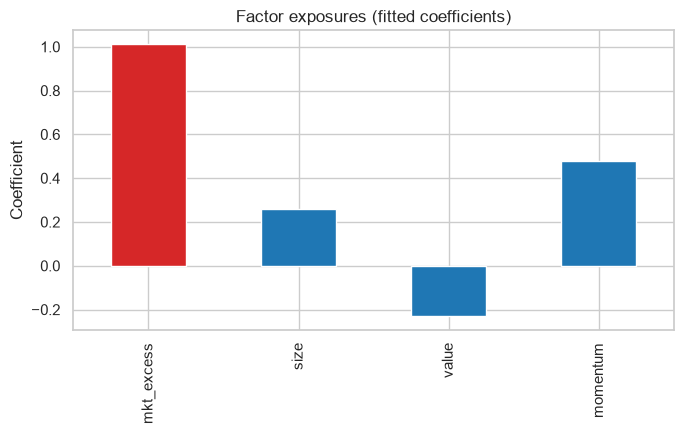

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
coef = pd.Series(model.coef_, index=FEATURES)
colors = ['tab:red' if n == 'mkt_excess' else 'tab:blue' for n in coef.index]
coef.plot(kind='bar', color=colors, ax=ax)
ax.set_title('Factor exposures (fitted coefficients)')
ax.set_ylabel('Coefficient')
fig.tight_layout()
fig.savefig(config.REPORTS_DIR / 'images' / 'factor_exposure.png', dpi=300, bbox_inches='tight')
plt.show()

## Stage 11 — Evaluation & risk (bootstrap CI + scenarios)

In [13]:
bm = evaluation.bootstrap_metric(y_test, y_pred, evaluation.mae, n_boot=600, seed=config.RANDOM_SEED)
print(f"MAE = {bm['mean']:.5f}   95% CI = [{bm['lo']:.5f}, {bm['hi']:.5f}]")

MAE = 0.00750   95% CI = [0.00594, 0.00932]


In [14]:
# Scenario sensitivity on the RAW data (still has missing 'value' + outliers).
raw = df.copy()

def prep(d, impute='median', outlier='winsorize'):
    d = d.copy()
    if impute == 'median':
        d['value'] = d['value'].fillna(d['value'].median())
    elif impute == 'mean':
        d['value'] = d['value'].fillna(d['value'].mean())
    elif impute == 'drop':
        d = d.dropna(subset=['value'])
    if outlier == 'winsorize':
        d['momentum'] = outliers.winsorize_series(d['momentum'], lower=0.01, upper=0.99)
    return d

scenarios = {
    'median_impute_winsor':   ('median', 'winsorize'),
    'mean_impute_winsor':     ('mean', 'winsorize'),
    'drop_winsor':            ('drop', 'winsorize'),
    'median_keep_outliers':   ('median', 'keep'),
}

rows = []
for name, (imp, out) in scenarios.items():
    d = prep(raw, impute=imp, outlier=out)
    Xs, ys = d[FEATURES].to_numpy(), d['asset_excess'].to_numpy()
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.2, shuffle=False)
    m = LinearRegression().fit(Xtr, ytr)
    yp = m.predict(Xte)
    rows.append({'scenario': name, 'n': len(d),
                 'mae': evaluation.mae(yte, yp), 'rmse': evaluation.rmse(yte, yp)})
sens = pd.DataFrame(rows)
base_mae = sens.loc[sens.scenario == 'median_impute_winsor', 'mae'].iloc[0]
sens['delta_mae'] = sens['mae'] - base_mae
sens.round(5)

,scenario,n,mae,rmse,delta_mae
0,median_impute_winsor,250,0.00749,0.00996,0.00000
1,mean_impute_winsor,250,0.00749,0.00996,-0.00000
2,drop_winsor,238,0.00720,0.00932,-0.00029
3,median_keep_outliers,250,0.00757,0.01019,0.00008


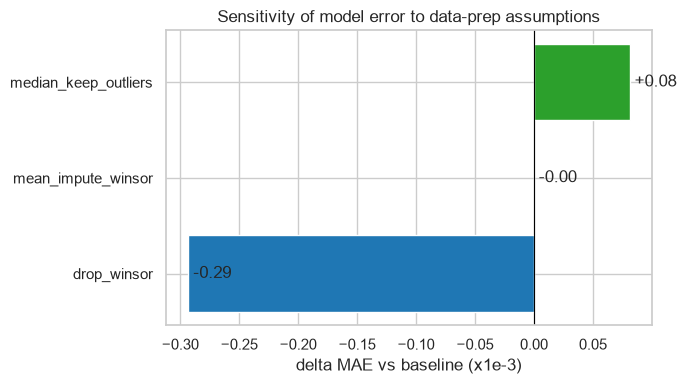

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
torn = sens.set_index('scenario').drop('median_impute_winsor').sort_values('delta_mae')
ax.barh(torn.index, torn['delta_mae'] * 1000, color=['tab:blue', 'tab:red', 'tab:green'])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('delta MAE vs baseline (x1e-3)')
ax.set_title('Sensitivity of model error to data-prep assumptions')
for i, (n, r) in enumerate(torn.iterrows()):
    ax.text(r['delta_mae'] * 1000, i, f" {r['delta_mae']*1000:+.2f}", va='center')
fig.tight_layout()
fig.savefig(config.REPORTS_DIR / 'images' / 'sensitivity_tornado.png', dpi=300, bbox_inches='tight')
plt.show()

sens.to_csv(config.DATA_DIR_PROCESSED / 'scenario_results.csv', index=False)
sens.to_json(config.DATA_DIR_PROCESSED / 'scenario_results.json', orient='records', indent=2)

## Stage 13 — Productization (save the model for the Flask API)

In [16]:
# Retrain on ALL cleaned data (not just train split) and save the final model.
final_model = LinearRegression().fit(X, y)
config.MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(final_model, config.MODEL_DIR / 'model.pkl')

reloaded = joblib.load(config.MODEL_DIR / 'model.pkl')
print('saved model/model.pkl')
print('prediction for [0.01, 0, 0, 0]:', float(reloaded.predict([[0.01, 0.0, 0.0, 0.0]])[0]))

saved model/model.pkl
prediction for [0.01, 0, 0, 0]: 0.009418818567822486


## Stage 13 — Productization (call the Flask API)

Start the server, then call it from this notebook with `requests` — a good POST, a good GET, a deliberately bad call, and the full-analysis route. This output is the testing evidence.

In [17]:
import subprocess, sys, time, socket
import requests

subprocess.Popen([sys.executable, 'app.py'],
                 stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

for _ in range(30):
    time.sleep(0.5)
    s = socket.socket(); s.settimeout(0.3)
    try:
        s.connect(('127.0.0.1', 5001)); s.close(); break
    except OSError:
        s.close()

BASE = 'http://127.0.0.1:5001'
r1 = requests.post(BASE + '/predict', json={'features': [0.01, 0.0, 0.0, 0.0]}, timeout=5)
print('POST /predict (good)      ', r1.status_code, r1.text.strip())

r2 = requests.get(BASE + '/predict/0.01/0.0/0.0/0.0', timeout=5)
print('GET  /predict/0.01/0/0/0  ', r2.status_code, r2.text.strip())

r3 = requests.get(BASE + '/predict/abc/0/0/0', timeout=5)
print('GET  /predict/abc/0/0/0   ', r3.status_code, r3.text.strip())

r4 = requests.get(BASE + '/run_full_analysis', timeout=5)
print('GET  /run_full_analysis   ', r4.status_code, r4.text[:140])


POST /predict (good)       200 {"prediction":0.009418818567822486}
GET  /predict/0.01/0/0/0   200 {"prediction":0.009418818567822486}
GET  /predict/abc/0/0/0    400 {"error":"path parameters must be numbers"}
GET  /run_full_analysis    200 [{"delta_mae":0.0,"mae":0.0074932725,"n":250,"rmse":0.0099557719,"scenario":"median_impute_winsor"},{"delta_mae":-1.422e-07,"mae":0.00749313


## Stage 15 — Orchestration

The `clean` task is also available as a standalone CLI script with logging:

```bash
python src/run_step.py --input data/raw/factor_returns.csv --output data/processed/cleaned_data.csv
```

See `docs/orchestration_plan.md` for the full six-task DAG.